# Generic Datamine access code

Check consistency

## Introduction

This is a script with the generic code to access Datamine Studio products using a Python Script.  It can be used in Notebook format or a normal Python file.
This script also contains testing code to check the connections are working correctly.
The installation of *dmstudio* is set up so that the Python script can be run from any directory on your machine.  However to make your life easier it is recommended to run the script from the active project directory or a dedicated Datamine_Scripts directory.
Before running Datamine processes it is usually easiest to change the Python working directory to the active project directory. This allows Datamine processes to find project files when only the Datamine file name is supplied.

 This script has three parts:
 - Installation of *dmstudio*
 - Testing the COM connection
 - Reconnecting to Studio/Changing projects in the same script.

Installation instructions for *dmstudio* are given in this script.  This is for Sean Horan's version of dmcommands not dmstudio-rm.
dmstudio-rm has some problems with the initialization and COM connection and does not work for some of the commands you will need for this course.
dmstudio needs a Patch to run and this is provided in the script.


COM connection testing requires a Studio app to be running and an active project opened. 
Change the working directory to the Datamine project.
Run tests to check the connection. Do not skip this stage, it will save you a lot of frustration and wasted time. 
Sometimes the connection does not work. You may need to close open windows and restart your machine to delete other COM objects.

Quitting and reconnecting have required steps for dropping the COM connection and/or quitting Studio and reconnecting. 
This section shows the options available and how to use them.
It also shows how to reconnect to Studio app without leaving the script and restarting Studio.


It is recommended to keep this script and use it for testing new installations and in a shortened format for testing connections on a new script.

Depending on your IDE you may see error messages like   "ActiveProject" is not a known attribute of "None"PylancereportOptionalMemberAccess.   Pylance is looking for variables/objects in the script and cannot find them because they are called, not defined.  These can be ignored they do not affect functionality.


## Install dmstudio

In order to use this code, installation of the *dmstudio* Python files is required.  The version below is from Sean Horan's GitHub page.    https://github.com/seanhoran/dmstudio .

**dmstudio* is set up for the geology/resource estimation software i.e. StudioEM, StudioRM.  A patch can be easily made for other Studio and related products to access the processes and commands.

**Step 1** download the *dmstudio* folder and put it into a folder on your machine.  I suggest creating a folder like  C:\Users\Your_Name\Datamine_Scripts  or put it under C:\Database   (the base Datamine folder).  Somewhere obvious so you can find it again.

**Step 2**  Using PowerShell or the terminal in VS Code find the location of your site packages your IDE is accessing 
 python -c "import site; print(site.getusersitepackages())"  you should get something like this:

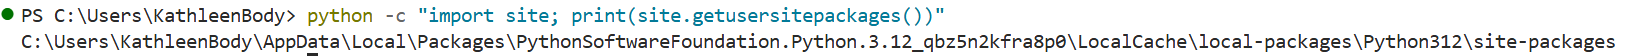

**Step 3** Create a text file called datamine_dmstudio.pth  
In the text file put the path to the dmstudio folder   ie  C:\Users\Your_Name\Datamine_Scripts   
Save to the site packages folder (C:\\Program files\\WindowsApps....\\site-packages) and check the extension does not have a txt.  File Explorer should see the file as a PTH file.  Then run the code block below.  If you do not see the correct file path check the PTH file that it has the correct file name and the file has a PTH extension.


In [ ]:
'''
Run this to check that Python can actually see the and read the .pth file.
If you do not see the correct file path check the PTH file that it has the correct file name and the file has a PTH extension.

'''

from pathlib import Path
import site

pth = Path(site.getusersitepackages()) / "datamine_dmstudio.pth"

print("File:", pth)
print("Exists:", pth.exists())
print("Contents:", repr(pth.read_text()))

**Step 4**  Patch required for *initilize.py*. There is a problem with the *initilaize.py* code. It is old and there has been a change in the NumPy packages since the original script was written. You will get an error when you try to initialize the dmcommands.
The file requires the patch below to run correctly.

Open the *initialize.py* file in dmstudio folder
Go to the bottom of the file and replace

>for infile in glob.glob("*.dm"):<br>
>>    outname = np.str.split(infile, '.')[0] <br>
>>    dmdir_f.write('_'+ outname + "_='" + outname + "'\n")<br>

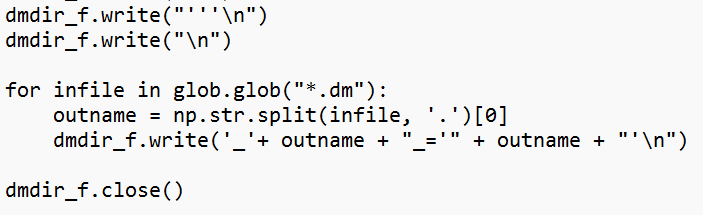

**************************************************************************************

with

>>for infile in glob.glob("*.dm"):<br>
>>>    outname = os.path.splitext(infile)[0]<br>
>>>    dmdir_f.write('_'+ outname + "_='" + outname + "'\n")<br>
dmdir_f. close()


**Note the indents!**

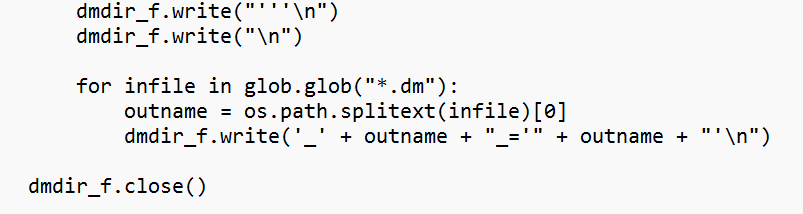

Save the file.



**Step 5** Test that "installation" 

Restart the kernel and in a separate code block run the following to check that the *dmstudio* can be found.<br>
<br>
    >import dmstudio

    >print(dmstudio.__file__)

If you do not see the correct file path check the PTH file that it has the correct file name, the path is correct and the file has a PTH extension. If you get an error read it carefully and fix the code (it will likely be in the initialize.py file- check the indents!)

In [ ]:
# Test Code

import dmstudio
print(dmstudio.__file__)

# This should show the file path to the dmstudio folder ( you will get a "pyrpa" error-ignore this it is not relevant to anything.)

 ## Start the full Connection test

*If this is the first installation run the tests on an existing project.  Access to some dm files is required.*

To test the connection set up run the following code blocks.
- Open Datamine Studio version you are using and connect to a project. An active Studio project must be opened before attempting to connect.
- Import the required Python packages. pandas, numpy and matplotlib are not needed at this point.
- If your script is not in the Studio project folder, change directories to point to the active project folder.
- Import the *dmstudio* packages
- Run the code blocks in order; follow the instructions in the code blocks for each test.

### Script Setup

In [ ]:

'''
Import Python packages
Below is a standard set of packages 
Choose which are needed.

'''

import os
import sys
#import pandas as pd   # abreviate to limit number of keystrokes with typing
#import numpy as np
#from matplotlib import pyplot as plt
import subprocess

In [ ]:
'''

Change to the active project directory. 
In my case it is the Oils_Sands_2024 folder.

'''

os.chdir("C:\\Database\\Oil_Sands_2024")

### Connect to Studio

The code block below sets the following  objects.
>> Python → dmstudio → Studio application → active project → project data

- **dmc** provides convenient Python helper functions for Datamine processes such as HOLES3D.
- **dmf** provides additional Datamine file/process helper functions.
- **studio** is the COM connection to the running Datamine Studio application.
- **project** represents the currently active Datamine project.
- **data** gives access to the project's loaded data objects.
- **special** provides data input and output helper functions

In [ ]:
'''

Run this code block.  It sets up a helper function to
import dmstudio and connect to the Studio app and runs the function.
You will see an error 
  "pyrpa module not found, only available to SLR employees" 
Ignore it, it does not affect the functionality. There are two superprocesses that require proprietary software to access. 
The superprocess.py file is not imported.

special 
        dmstudio special helper functions module. special is imported as a module and can be called directly not from connect_to_datamine
        
'''


from dmstudio import dmcommands, dmfiles, special


def connect_to_datamine():
    """
    Connect to Datamine Studio RM and return the main working objects.

    Returns
    -------
    dmc
        dmstudio command/helper interface.
    dmf
        dmfiles interface for commands that do not use input files.    
    studio
        Datamine Studio RM COM application object.
    project
        Active Datamine project COM object.
    data
        Active Project's Data COM object.
    """

   
    dmc = dmcommands.init(version="StudioRM")  # edit version/application
    dmf = dmfiles.init(version = "StudioRM")   # edit version/application

    studio = dmc.oScript                       # oScript is set up when *dmstudio* initializes

    project = studio.ActiveProject
    if project is None:
        raise RuntimeError(
            "Connected to Datamine Studio RM, "
            "but no active project is open."
        )

    data = project.Data

    return dmc, dmf, studio, project, data

'''

run the helper function to connect to Datamine and set up the objects.

'''

dmc, dmf, studio, project, data = connect_to_datamine()

### Run Connection test for commands, processes and dialogs

**COMMANDS** can be accessed through **studio**.  Datamine interface commands can be sent directly to Studio using studio.ParseCommand(). These include commands that open dialogs or control parts of the Studio interface. ParseCommand() sends a Datamine command string to the running Studio application.

**PROCESSES** can be accessed through **dmcommands, dmfiles and special**  Datamine processes such as HOLES3D can be run using the helper functions provided by dmcommands(dmc), dmfiles(dmf) and special.

**TABLES** can be launched through **subprocess**.   subprocess can be used to open a Datamine file in the external Datamine Table Editor. subprocess is used to open any external app i.e. .exe files. This is useful here for checking the output files produced by the test process.
There are other ways to access tables but we need to test the subprocess method here and this is easy.


In [ ]:
'''
Test a dialog connection

Run the following command. You will see a window pop up in Datamine.  
The code keeps running until the window is closed.
You can then move onto the next block.

You may get a Pylance error in your IDE. this can be ignored, I does not affect the functionality

'''

studio.ParseCommand("show-system-options")  # all commands are passed to Datamine as "strings" ,   not strings or 'strings'  use the correct string identifiers

In [ ]:
'''
Tests a window function

Run the following command. You will see the loaded data window appear.  
Run a second time to close the loaded Data window.  

You may get a Pylance error in your IDE. this can be ignored, I does not affect the funtionality

'''

studio.ParseCommand("toggle-loaded-data-bar")  # manually close the window

In [ ]:
'''
Test a process HOLES3D

If you have borehole data you can run this test to check that the processes run correctly.
Replace folder, test_out, test_err and test_smry with your filenames.
When the test is complete run the second code block to delete the test files.

dmcommands wraps Datamine processes as Python functions. 
The Datamine process parameters are supplied as Python keyword arguments. 
For example, collar_i corresponds to the 
collar input file and out_o specifies the output file.

'''
folder = "C:\\Database\\Oil_Sands_2024\\"
ext = ".dm"
test_out ='holes_py3tx'
test_smry ='holes_py3tx_smry'
test_err = 'holes_py3tx_err'
dmc.holes3d(collar_i='collars_py',
           samples_i=['assays_py', 'geology_py'],
           survey_i='optional',
           out_o=test_out, 
           holesmry_o=test_smry, 
           errors_o= test_err,
           bhid_f='BHID',
           xcollar_f='XCOLLAR',
           ycollar_f='YCOLLAR',
           zcollar_f='ZCOLLAR',
           from_f='FROM',
           to_f='TO',
           survsmth_p='1.0',
           dipmeth_p='0.0',
)

filename = os.path.join(folder,test_err + ext)
subprocess.run(["C:\\Program Files\\Datamine\\Table Editor\\TableEditorME.exe",filename])
filename = os.path.join(folder,test_smry + ext)
subprocess.run(["C:\\Program Files\\Datamine\\Table Editor\\TableEditorME.exe",filename])
filename = os.path.join(folder,test_out + ext)
subprocess.run(["C:\\Program Files\\Datamine\\Table Editor\\TableEditorME.exe",filename])

#### Documentation
Record the results of the valdation of the desurveying

In [ ]:
#delete test files after test

os.remove(os.path.join(folder,test_err + ext))
os.remove(os.path.join(folder,test_smry + ext))
os.remove(os.path.join(folder,test_out + ext))

The following tests are optional and generally only needed on the first installation to check that Python is seeing the COM object.

In [ ]:
'''

Test loading files on an existing Datamine project file.

LoadFromProject() loads a Datamine project file and returns 
a Python COM object representing the loaded object. 
Once Python has this object, methods belonging to that 
Datamine object can be called from Python.
hasattr is simply checking whether that loaded COM object exposes the method SaveAsDatamineFile.

Unload all data from your 3D window.
Choose a file from your project.
The file should load into the 3D window.
The file should also be passed to the object "loaded".

expected return

Loaded object: <COMObject LoadFromProject>
Loaded type: <class 'win32com.client.CDispatch'>
Has SaveAsDatamineFile: True

If you do not see the above, the file did not load because the connection was not established.
If the prior tests worked this should have worked.

'''

test_file = "holes_py3t"   # choose a relevant file

loaded = data.LoadFromProject(test_file)   # check the 3D window for the loaded object

print("Loaded object:", loaded)
print("Loaded type:", type(loaded))

print(
    "Has SaveAsDatamineFile:",
    hasattr(loaded, "SaveAsDatamineFile")   # this becomes important later when saving a file is needed.
)


In [ ]:
'''
Returns a data object only loads and saved dm, dmx files.
Check for project file.
SaveAsDatamineFile only works for  dm files loaded with  LoadFromProject.

'''

loaded.SaveAsDatamineFile("holes_py3t_x", project.ExtendedPrecision, True, "")

In [ ]:
'''
UnloadAll() removes all currently loaded data objects # from the Studio 3D window. 
It does not delete the Datamine files.
'''

data.UnloadAll()

In [ ]:
'''
LoadExternal() opens Studio's interface for loading external data into the ActiveProject.  
This opens a dialog to import text files and Datamine tables and connect to databases.
'''

data.LoadExternal() 


In [ ]:
# Calls the active project's Datamine Import Files dialog.

project.ImportFiles()  #this option is interactive and not auditable

In [ ]:
'''
Below is another way to import a csv.

Reads the CSV structure and creates a Datamine-style 
field definition that can be examined or modified before import.

'''

#import special
definition = special.csv_to_definition('Collars.csv')
print(definition[definition['Field Name'].isin(['XCOLLAR','YCOLLAR','ZCOLLAR'])])

In [ ]:
'''
A helper function for importing the CSV into a Datamine file using the INPFIL process.

Notes
The .csv extension needs to be added to the input filename.
Do not addthe .dm extension to output filename.
Leave definition=None
In the Datamine command window there is an error message about blank spaces before the Field Name, 
There is no space and the file imports correctly.  Why this message occurs needs investigation.

'''

os.chdir("C:\\Database\\Oil_Sands_2024")
special.inpfil(csv='Collars.csv', out_o = 'collarsdm_test', definition = None )  

In [ ]:
'''
The command below opens the export dialog.

Or, export to CSV using the Table Editor.

'''

studio.ParseCommand("export")   # this brings up the export dialog in Datamine

#Table editor code
#filename = "C:\\Database\\Oil_Sands_2024\\holes_py3t.dm"
#subprocess.run(["C:\\Program Files\\Datamine\\Table Editor\\TableEditorME.exe",filename])  verify and save as CSV.


In [ ]:
'''
It is important to explictly close the COM connection.
If you want to quit Studio and save your file use studio.Quit(). It opens the quit/save file dialog in Studio and shuts down the software.
Using del (delete) destroys the COM objects and relaease the COM connection, but does not close Studio. You can continue working in Studio.
Use del if you want to continue working in Datamine outside of the script but do not want to Quit the script or Studio.
It is safer. If Studio crashes it may not destroy the COM object and when you try to reconnect the connection does not work the correct way.

'''

studio.Quit()   # This sends a command to open the dialog to quit Datamine and Save the project.

#del studio, dmc,dmf,project, data       # deletes all COM objects but does not close Studio. Use this if you want to continue working in Datamine outside of the script but do not want to Quit the script or DStudio


# Changing projects without changing scripts or reconnecting to Studio without quitting the application

To change projects in the same script without closing Studio.
Follow the steps below.

In [ ]:
'''
Use this block if you need to change projects.

To reconnect to the same project skip to the next block.

OpenProject() tells the already-running Studio application (i.e. StudioRM) to open another project.
This closes the active project and opens the new project. 

First change projects in Studio using the command below.
Second change directories and reinitialize dmstudio and test using the second code block.

'''

studio.OpenProject("C:\\Database\\DM_Test_project\\DM_test_project.rmproj")  
 


In [ ]:
'''
The Python working directory is then changed to the new project directory. 
Finally, connect_to_datamine() is run again so that project and data refer
to the newly active project rather than the previous one.

Check connection with the ImportFiles() dialog call

'''

os.chdir("C:\\Database\\DM_Test_project")

dmc, dmf, studio, project, data = connect_to_datamine()

project.ImportFiles()


In [ ]:
'''
To reconnect after using del run connect_to_datamine() again
To reconnect after Quitting Studio , open Studio and connect to a project then run connect_to_datamine()

'''
dmc, dmf, studio, project, data = connect_to_datamine()


In [ ]:
'''
Test the connection
'''
studio.ParseCommand("show-system-options")  # all commands are passsed to Datamine as "strings" ,   not strings or 'strings'